In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

In [44]:
df = pd.read_csv("C:/Users/user/OneDrive/Documents/Learn AI/ML_Projects/social-media-segmantation/dataset/Social Media Engagement Dataset.csv")

In [45]:
df.head()

,post_id,timestamp,day_of_week,platform,user_id,location,language,text_content,hashtags,mentions,...,comments_count,impressions,engagement_rate,brand_name,product_name,campaign_name,campaign_phase,user_past_sentiment_avg,user_engagement_growth,buzz_change_rate
0,kcqbs6hxybia,2024-12-09 11:26:15,Monday,Instagram,user_52nwb0a6,"Melbourne, Australia",pt,Just tried the Chromebook from Google. Best pu...,#Food,NaN,...,701,18991,0.19319,Google,Chromebook,BlackFriday,Launch,0.0953,-0.3672,19.1
1,vkmervg4ioos,2024-07-28 19:59:26,Sunday,Twitter,user_ucryct98,"Tokyo, Japan",ru,Just saw an ad for Microsoft Surface Laptop du...,"#MustHave, #Food","@CustomerService, @BrandCEO",...,359,52764,0.05086,Microsoft,Surface Laptop,PowerRelease,Post-Launch,0.1369,-0.4510,-42.6
2,memhx4o1x6yu,2024-11-23 14:00:12,Saturday,Reddit,user_7rrev126,"Beijing, China",ru,What's your opinion about Nike's Epic React? ...,"#Promo, #Food, #Trending",NaN,...,643,8887,0.45425,Nike,Epic React,BlackFriday,Post-Launch,0.2855,-0.4112,17.4
3,bhyo6piijqt9,2024-09-16 04:35:25,Monday,YouTube,user_4mxuq0ax,"Lagos, Nigeria",en,Bummed out with my new Diet Pepsi from Pepsi! ...,"#Reviews, #Sustainable","@StyleGuide, @BrandSupport",...,743,6696,0.42293,Pepsi,Diet Pepsi,LaunchWave,Launch,-0.2094,-0.0167,-5.5
4,c9dkiomowakt,2024-09-05 21:03:01,Thursday,Twitter,user_l1vpox2k,"Berlin, Germany",hi,Just tried the Corolla from Toyota. Absolutely...,"#Health, #Travel","@BrandSupport, @InfluencerName",...,703,47315,0.08773,Toyota,Corolla,LocalTouchpoints,Launch,0.6867,0.0807,38.8


In [46]:
df.shape

(12000, 28)

***data preprocessing***


Null value removing

In [47]:
df.isnull().sum()

post_id                       0
timestamp                     0
day_of_week                   0
platform                      0
user_id                       0
location                      0
language                      0
text_content                  0
hashtags                      0
mentions                   3941
keywords                      0
topic_category                0
sentiment_score               0
sentiment_label               0
emotion_type                  0
toxicity_score                0
likes_count                   0
shares_count                  0
comments_count                0
impressions                   0
engagement_rate               0
brand_name                    0
product_name                  0
campaign_name                 0
campaign_phase                0
user_past_sentiment_avg       0
user_engagement_growth        0
buzz_change_rate              0
dtype: int64

In [48]:
df["mentions"] = df["mentions"].fillna("")

In [49]:
df.isnull().sum()

post_id                    0
timestamp                  0
day_of_week                0
platform                   0
user_id                    0
location                   0
language                   0
text_content               0
hashtags                   0
mentions                   0
keywords                   0
topic_category             0
sentiment_score            0
sentiment_label            0
emotion_type               0
toxicity_score             0
likes_count                0
shares_count               0
comments_count             0
impressions                0
engagement_rate            0
brand_name                 0
product_name               0
campaign_name              0
campaign_phase             0
user_past_sentiment_avg    0
user_engagement_growth     0
buzz_change_rate           0
dtype: int64

In [50]:
df.shape

(12000, 28)

select important features

In [51]:
df.value_counts("platform")

platform
YouTube      2436
Facebook     2431
Twitter      2406
Reddit       2372
Instagram    2355
Name: count, dtype: int64

In [52]:
df.value_counts("campaign_phase")

campaign_phase
Pre-Launch     4006
Launch         4004
Post-Launch    3990
Name: count, dtype: int64

In [53]:
df.value_counts("sentiment_label")

sentiment_label
Negative    4854
Positive    4839
Neutral     2307
Name: count, dtype: int64

In [54]:
df.value_counts("emotion_type")

emotion_type
Sad         2504
Excited     2436
Confused    2393
Happy       2350
Angry       2317
Name: count, dtype: int64

get important catogorical columns 

In [55]:
cat_cols = ["platform","topic_category","campaign_phase","sentiment_label","emotion_type"]

In [56]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
for col in cat_cols:
    le = LabelEncoder()
    df[col+"_enc"] = le.fit_transform(df[col].astype(str))

In [57]:
df["hashtag_count"] = df["hashtags"].astype(str).apply(lambda x: x.count("#"))
df["keyword_count"] = df["keywords"].astype(str).apply(lambda x: len([i for i in x.split(",") if i.strip() != ""]))

select important features for clustering

| Feature                  | Meaning                        |
| ------------------------ | ------------------------------ |
| Content_Intent_Score     | what type of content it is     |
| Emotion_Reputation_Score | how positive/trustworthy it is |
| Influence_Impact_Score   | how viral it is                |


In [58]:
df["Content_Intent_Score"] = (
    df["platform_enc"] +
    df["topic_category_enc"] +
    df["campaign_phase_enc"] +
    df["hashtag_count"] +
    df["keyword_count"]
)

df["Emotion_Reputation_Score"] = (
    df["sentiment_score"] * 3 +
    df["sentiment_label_enc"] +
    df["emotion_type_enc"] +
    df["user_past_sentiment_avg"] * 2 -
    df["toxicity_score"] * 4
)

df["Influence_Impact_Score"] = (
    np.log1p(df["likes_count"]) +
    np.log1p(df["shares_count"] * 2) +
    np.log1p(df["comments_count"] * 2) +
    np.log1p(df["impressions"]) +
    df["engagement_rate"] * 50 +
    df["user_engagement_growth"] * 5 +
    df["buzz_change_rate"] / 10
)

In [59]:
df_final =df[[
    "Content_Intent_Score",
    "Emotion_Reputation_Score",
    "Influence_Impact_Score"
]]


In [60]:
df_final.shape

(12000, 3)

In [61]:
df_final.isnull().sum()

Content_Intent_Score        0
Emotion_Reputation_Score    0
Influence_Impact_Score      0
dtype: int64

In [62]:
df_final.head()

,Content_Intent_Score,Emotion_Reputation_Score,Influence_Impact_Score
0,8,5.9880,42.108643
1,8,-4.7501,27.929678
2,13,-1.5574,53.798377
3,10,-0.2042,50.401307
4,12,7.6666,42.255690


In [63]:
(df["Emotion_Reputation_Score"] < 0).sum()

np.int64(4778)

In [64]:
(df["Content_Intent_Score"] < 0).sum()

np.int64(0)

In [65]:
(df["Influence_Impact_Score"] < 0).sum()

np.int64(0)

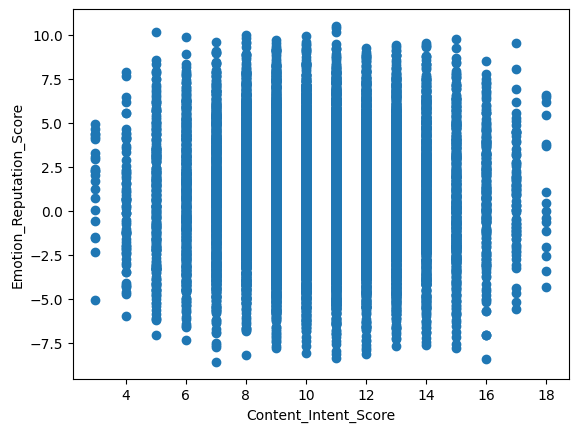

In [66]:
plt.scatter(df_final["Content_Intent_Score"], df_final["Emotion_Reputation_Score"])
plt.xlabel("Content_Intent_Score")
plt.ylabel("Emotion_Reputation_Score")
plt.show()

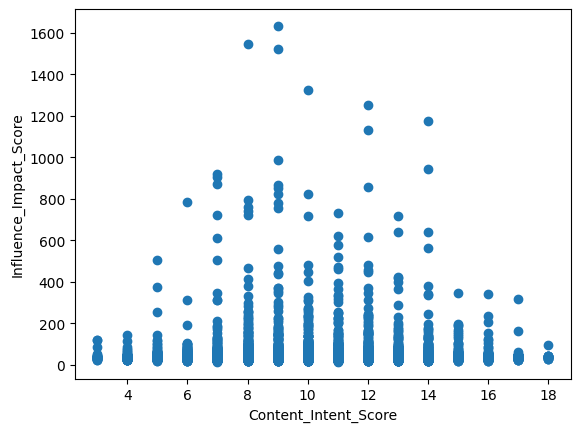

In [67]:
plt.scatter(df_final["Content_Intent_Score"], df_final["Influence_Impact_Score"])
plt.xlabel("Content_Intent_Score")
plt.ylabel("Influence_Impact_Score")
plt.show()

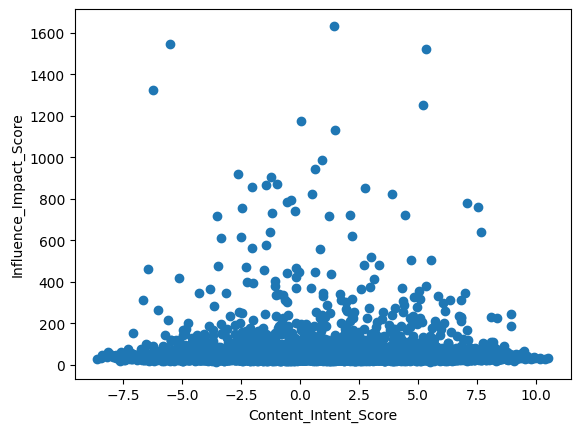

In [68]:
plt.scatter(df_final["Emotion_Reputation_Score"], df_final["Influence_Impact_Score"])
plt.xlabel("Content_Intent_Score")
plt.ylabel("Influence_Impact_Score")
plt.show()

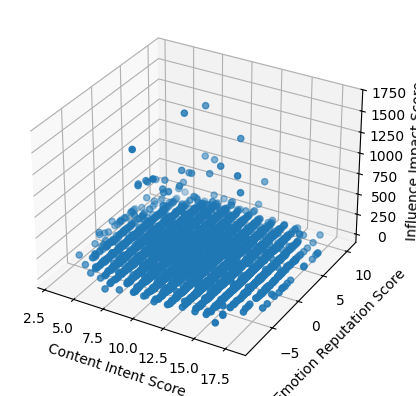

In [69]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# select features
df_final = df[[
    "Content_Intent_Score",
    "Emotion_Reputation_Score",
    "Influence_Impact_Score"
]]

# 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df_final["Content_Intent_Score"],
    df_final["Emotion_Reputation_Score"],
    df_final["Influence_Impact_Score"]
)

ax.set_xlabel("Content Intent Score")
ax.set_ylabel("Emotion Reputation Score")
ax.set_zlabel("Influence Impact Score")

plt.show()

Scale data

In [70]:
scaler = StandardScaler()
df_final_scaled = scaler.fit_transform(df_final)

In [71]:
df_final_scaled = pd.DataFrame(df_final_scaled,columns=['Content_Intent_Score','Emotion_Reputation_Score','Influence_Impact_Score'])
df_final_scaled.head()

,Content_Intent_Score,Emotion_Reputation_Score,Influence_Impact_Score
0,-0.944494,1.467665,-0.066898
1,-0.944494,-1.701732,-0.314505
2,0.955196,-0.759392,0.137240
3,-0.184618,-0.359990,0.077917
4,0.575258,1.963111,-0.064330


visualize scaler data

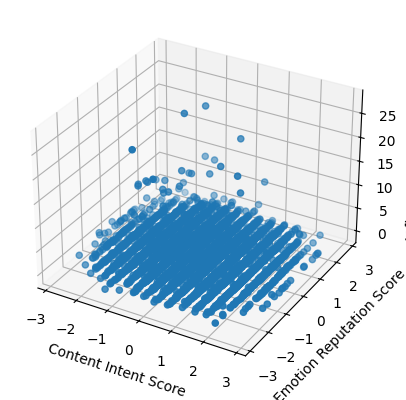

In [72]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import pandas as pd


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df_final_scaled["Content_Intent_Score"],
    df_final_scaled["Emotion_Reputation_Score"],
    df_final_scaled["Influence_Impact_Score"]
)

ax.set_xlabel("Content Intent Score")
ax.set_ylabel("Emotion Reputation Score")
ax.set_zlabel("Influence Impact Score")

plt.show()

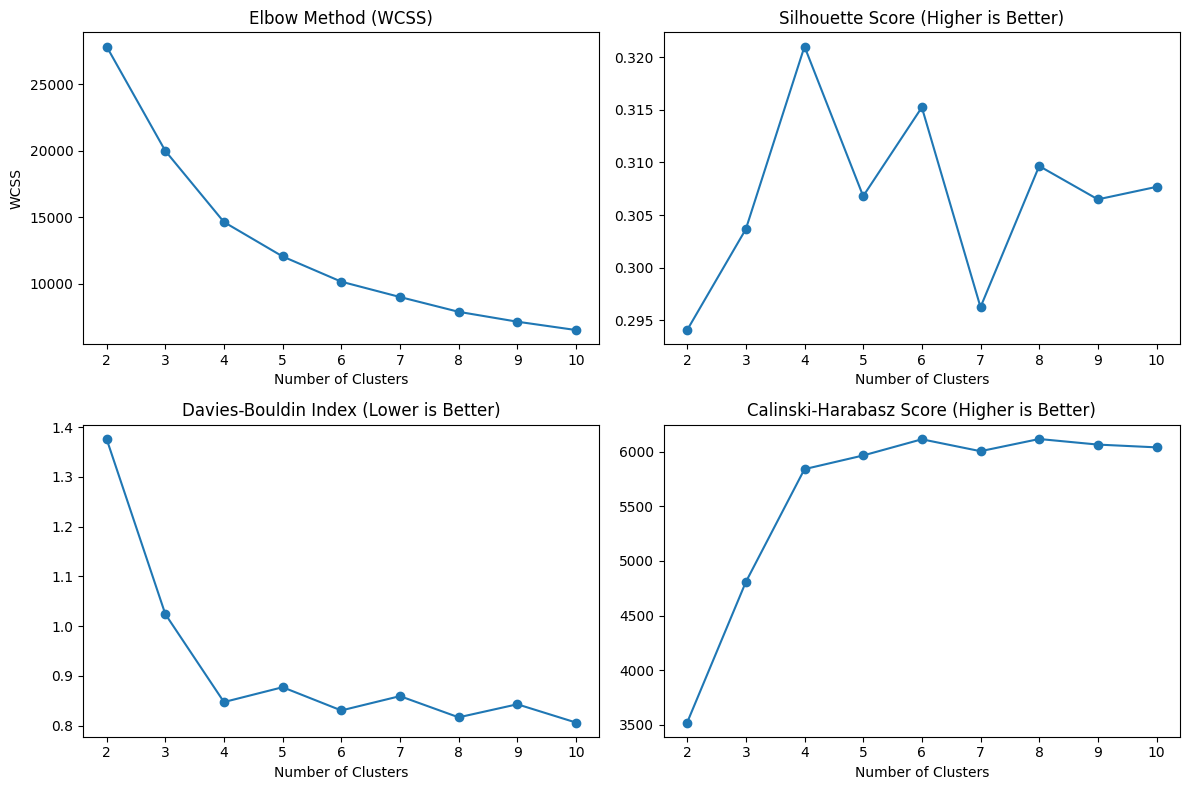

In [73]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt

wcss = []
silhouette_scores = []
db_scores = []
ch_scores = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = kmeans.fit_predict(df_final_scaled)

    # WCSS (Elbow)
    wcss.append(kmeans.inertia_)

    # Metrics
    silhouette_scores.append(silhouette_score(df_final_scaled, labels))
    db_scores.append(davies_bouldin_score(df_final_scaled, labels))
    ch_scores.append(calinski_harabasz_score(df_final_scaled, labels))

# Plot results
plt.figure(figsize=(12, 8))

# Elbow (WCSS)
plt.subplot(2, 2, 1)
plt.plot(K_range, wcss, marker='o')
plt.title('Elbow Method (WCSS)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

# Silhouette Score
plt.subplot(2, 2, 2)
plt.plot(K_range, silhouette_scores, marker='o')
plt.title('Silhouette Score (Higher is Better)')
plt.xlabel('Number of Clusters')

# Davies-Bouldin
plt.subplot(2, 2, 3)
plt.plot(K_range, db_scores, marker='o')
plt.title('Davies-Bouldin Index (Lower is Better)')
plt.xlabel('Number of Clusters')

# Calinski-Harabasz
plt.subplot(2, 2, 4)
plt.plot(K_range, ch_scores, marker='o')
plt.title('Calinski-Harabasz Score (Higher is Better)')
plt.xlabel('Number of Clusters')

plt.tight_layout()
plt.show()

Number of cluster = 4

training the K-means Clustering Model

In [74]:
model = KMeans(n_clusters=4, init = 'k-means++', n_init=10,random_state=42)

pred = model.fit_predict(df_final_scaled)

print(pred[:50])

[0 2 1 2 0 1 1 0 2 1 0 2 0 0 2 1 1 2 0 1 1 1 2 1 2 0 1 1 1 2 1 1 0 1 0 1 2
 1 0 0 1 1 1 0 0 1 0 1 2 2]


In [ ]:
df_final_scaled['Cluster'] = pred

df_final_scaled.head()

,Content_Intent_Score,Emotion_Reputation_Score,Influence_Impact_Score,Cluster
0,-0.944494,1.467665,-0.066898,0
1,-0.944494,-1.701732,-0.314505,2
2,0.955196,-0.759392,0.137240,1
3,-0.184618,-0.359990,0.077917,2
4,0.575258,1.963111,-0.064330,0


In [ ]:
df.to_csv('clustered_Social_media1_data.csv',index = False)
print("successfully cluster labels aded csv saved")

successfully cluster labels aded csv saved


In [77]:
c1 = df_final_scaled[df_final_scaled['Cluster'] == 0]
c2 = df_final_scaled[df_final_scaled['Cluster'] == 1]
c3 = df_final_scaled[df_final_scaled['Cluster'] == 2]
c4 = df_final_scaled[df_final_scaled['Cluster'] == 3]


In [78]:
c1.head()

,Content_Intent_Score,Emotion_Reputation_Score,Influence_Impact_Score,Cluster
0,-0.944494,1.467665,-0.066898,0
4,0.575258,1.963111,-0.064330,0
7,-0.184618,0.138054,-0.070520,0
10,0.575258,0.699349,-0.125854,0
12,1.335134,1.197274,0.067150,0


In [79]:
c2.head()

,Content_Intent_Score,Emotion_Reputation_Score,Influence_Impact_Score,Cluster
2,0.955196,-0.759392,0.137240,1
5,0.195320,-0.455649,0.299235,1
6,0.955196,-1.580895,-0.142143,1
9,0.955196,-1.418472,-0.238138,1
15,0.575258,-1.014671,0.576707,1


In [80]:
c3.head()

,Content_Intent_Score,Emotion_Reputation_Score,Influence_Impact_Score,Cluster
1,-0.944494,-1.701732,-0.314505,2
3,-0.184618,-0.359990,0.077917,2
8,-1.704370,0.340559,-0.268171,2
11,-0.184618,0.016893,-0.057464,2
14,-0.184618,-1.045131,0.093612,2


In [81]:
c4.head()

,Content_Intent_Score,Emotion_Reputation_Score,Influence_Impact_Score,Cluster
152,-0.944494,-0.405001,13.067510,3
383,0.195320,-0.647411,11.970689,3
635,-1.324432,-1.069186,15.278137,3
719,-0.564556,1.280419,25.742134,3
914,-0.564556,1.787110,12.814159,3


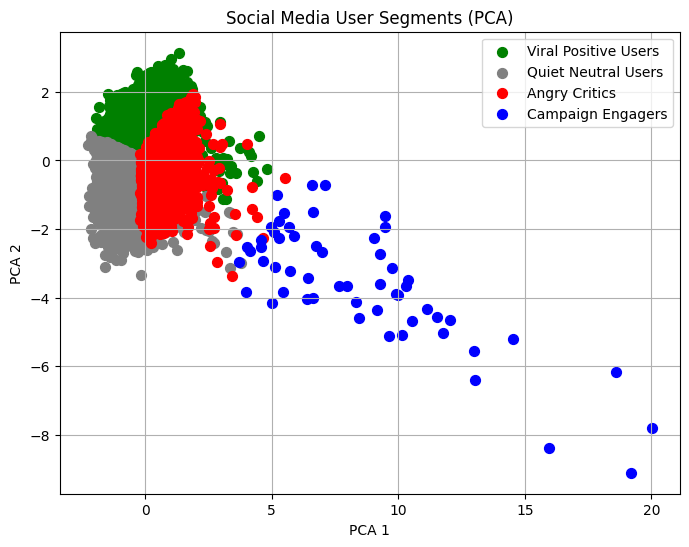

In [82]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


pca = PCA(n_components=2)
reduced = pca.fit_transform(df_final_scaled.drop('Cluster', axis=1))

cluster_names = {
    0: "Viral Positive Users",
    1: "Quiet Neutral Users",
    2: "Angry Critics",
    3: "Campaign Engagers"
}

plt.figure(figsize=(8,6))

colors = ['green', 'gray', 'red', 'blue']

for i in range(4):
    plt.scatter(
        reduced[df_final_scaled['Cluster'] == i, 0],
        reduced[df_final_scaled['Cluster'] == i, 1],
        color=colors[i],
        label=cluster_names[i],
        s=50
    )

plt.title("Social Media User Segments (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.grid(True)
plt.show()

In [83]:
from sklearn.preprocessing import MinMaxScaler

# PCA
pca = PCA(n_components=2)
reduced = pca.fit_transform(df_final_scaled.drop('Cluster', axis=1))

# Convert to DataFrame
reduced_df = pd.DataFrame(reduced, columns=['PC1', 'PC2'])

# Scale to 0–1 range (NO negatives)
scaler = MinMaxScaler()
reduced_scaled = scaler.fit_transform(reduced_df)

reduced_scaled = pd.DataFrame(reduced_scaled, columns=['PC1', 'PC2'])

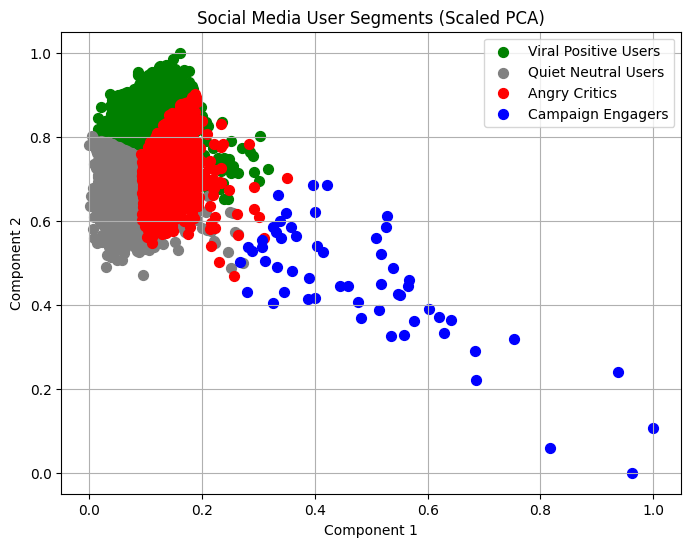

In [84]:
plt.figure(figsize=(8,6))

colors = ['green', 'gray', 'red', 'blue']

for i in range(4):
    plt.scatter(
        reduced_scaled[df_final_scaled['Cluster'] == i]['PC1'],
        reduced_scaled[df_final_scaled['Cluster'] == i]['PC2'],
        color=colors[i],
        label=cluster_names[i],
        s=50
    )

plt.title("Social Media User Segments (Scaled PCA)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend()
plt.grid(True)
plt.show()

In [85]:
# Cluster Profile Validation
cluster_profile = df_final.copy()
cluster_profile['Cluster'] = pred
cluster_summary = cluster_profile.groupby('Cluster').mean().round(2)
cluster_summary.index = cluster_summary.index.map(cluster_names)
print(cluster_summary)

                      Content_Intent_Score  Emotion_Reputation_Score  \
Cluster                                                                
Viral Positive Users                 10.37                      4.56   
Quiet Neutral Users                  12.88                     -0.83   
Angry Critics                         8.08                     -0.95   
Campaign Engagers                     9.98                      0.29   

                      Influence_Impact_Score  
Cluster                                       
Viral Positive Users                   43.23  
Quiet Neutral Users                    42.42  
Angry Critics                          42.61  
Campaign Engagers                     723.94  
